In [15]:
from sklearn.datasets import load_digits
from matplotlib import pyplot as plt
from sklearn.decomposition import *
from sklearn.manifold import TSNE
from sklearn.svm import *
from sklearn.ensemble import RandomForestClassifier
# from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

First let's load our MNIST digits dataset from Scikit-Learn library

In [2]:
data = load_digits()
print(data.data.shape)            # This is the shape of the data
print(data.feature_names, data.target_names)   
print(data.images[0])            # This is the image of the digit
print(data.target)               # This is the label of the digit


(1797, 64)
['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7'] [0 1 2 3 4 5 6 7 8 9]
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.

Basically, our dataset is composed of 1797 hand-written digits (from 0 - 9) each of which has 8*8=64 pixels. 
First thing first, we visualize our data by creating a grid layout of random MNIST digit images. 

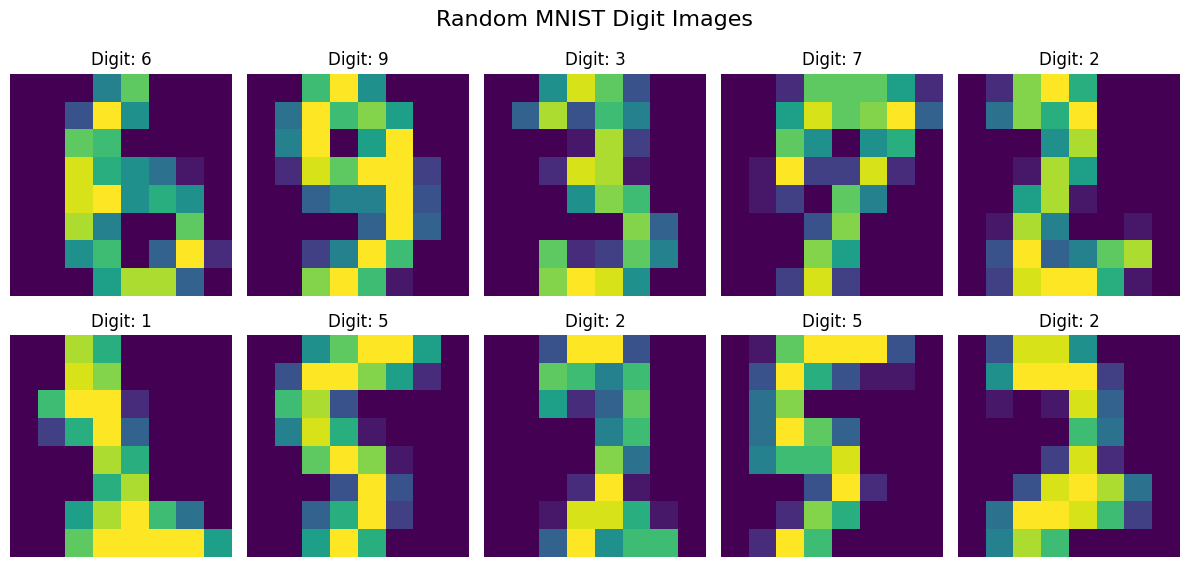

In [3]:
import numpy as np

# Create a subplot grid to display multiple random images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Random MNIST Digit Images', fontsize=16)

# Flatten the axes array for easier indexing
axes = axes.ravel()

# Select random indices
np.random.seed(42)  # For reproducible results
random_indices = np.random.choice(len(data.images), size=10, replace=False)

# Plot each random image
for i, idx in enumerate(random_indices):
    axes[i].imshow(data.images[idx])
    axes[i].set_title(f'Digit: {data.target[idx]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


It is utterly important to understand the data before doing any machine learning (ML) analsys. One crucial way to find out which ML algorithms to implement and how to proceed is to take DIMENSIONALITY REDUCTION methods.

### Now let's Create a dictionary of dimensionality reduction algorithms. The keys are the names of the algorithms, and the values are the algorithm classes

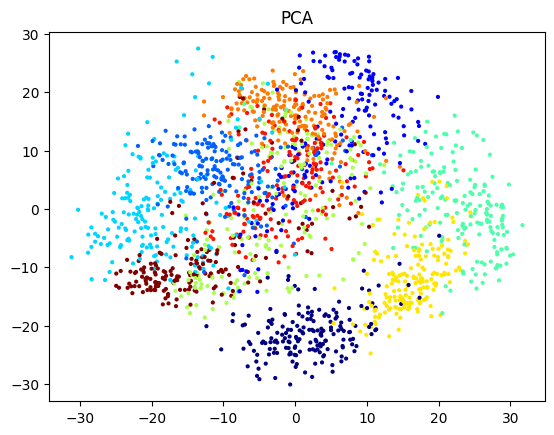

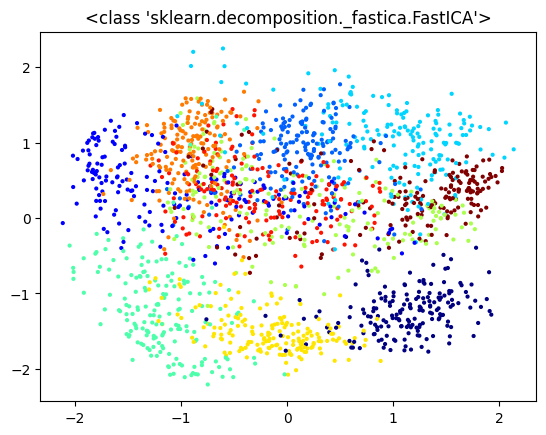

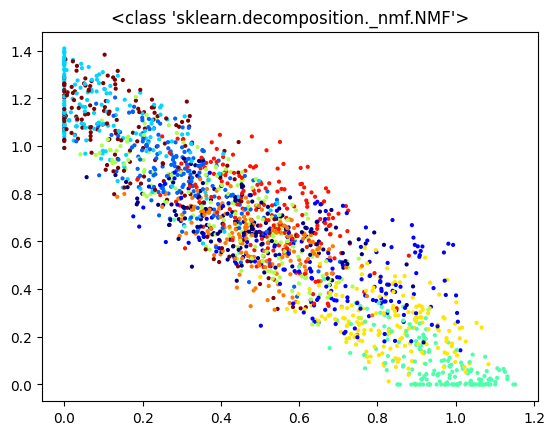

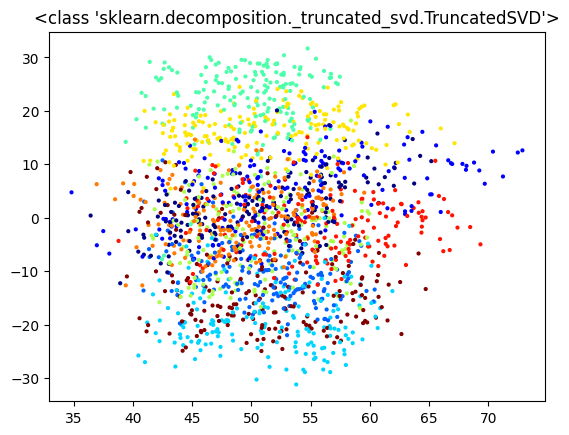

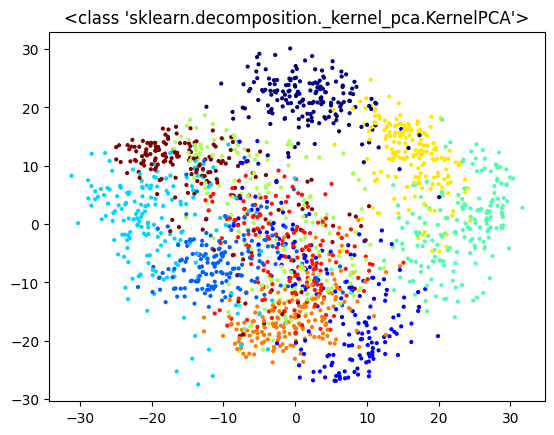

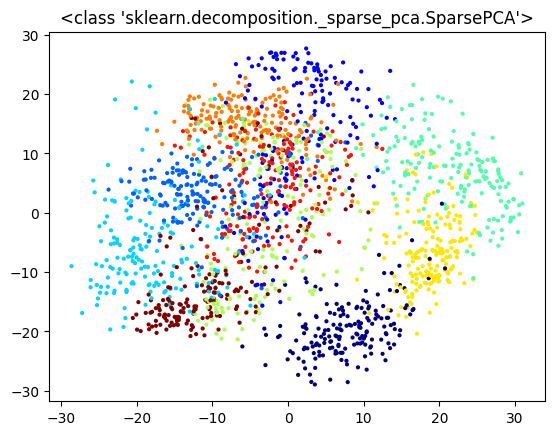

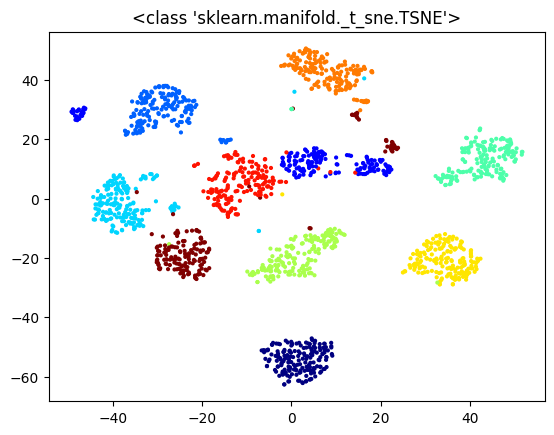

In [11]:
algs = {"PCA":PCA, FastICA:FastICA, NMF:NMF, TruncatedSVD:TruncatedSVD, KernelPCA:KernelPCA, SparsePCA:SparsePCA, TSNE:TSNE}

# Iterate over the dictionary of algorithms
for name, alg in algs.items():
    pca = alg(n_components=2)  # Instantiate the algorithm with 2 components
    tr = pca.fit_transform(data.data) # Fit and transform the data
    plt.figure()
    plt.title(name)
    plt.scatter(tr[:, 0], tr[:, 1], c=data.target, cmap='jet', s=4)

### Among all, tSNE did an extremely good jon on our dataset

Now we split our dataset into training and testing sets. We will use 80% of the data for training and the remaining 20% for testing. The `train_test_split` function from scikit-learn is used for this purpose.

In [17]:
x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42) 
print(x_train.shape, x_test.shape)

(1437, 64) (360, 64)


In the following section we iterates through a couple of classification algorithms, namely Support Vector Classifier (SVC) and Random Forest Classifier. For each algorithm, it performs the following steps:
1.  Instantiates the classifier with default parameters.
2.  Trains the model on the `x_train` and `y_train` data.
3.  Evaluates the model's accuracy on the test set (`x_test`, `y_test`) and prints the result.
4.  Generates predictions for the test set.
5.  Computes and displays a confusion matrix to visualize the performance of the classifier.

SVC accuracy: 0.9861111111111112
RandomForest accuracy: 0.9777777777777777


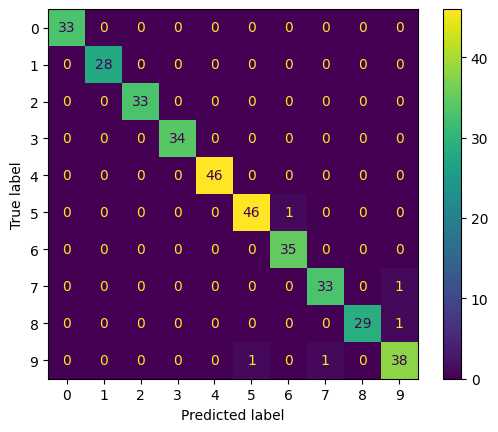

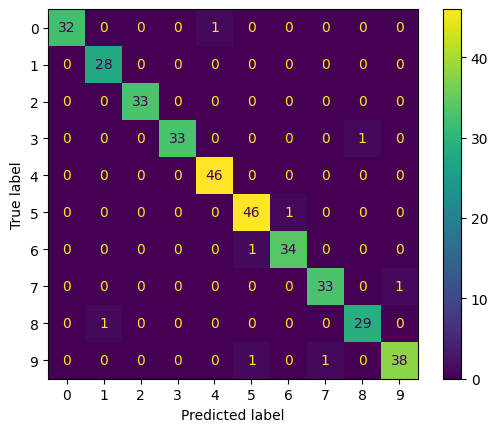

In [18]:
cls_algs = {"SVC":SVC, "RandomForest":RandomForestClassifier}
for name, alg in cls_algs.items():
    cls = alg()  # Instantiate the algorithm with default parameters
    cls.fit(x_train, y_train) # Fit the model
    print(f"{name} accuracy: {cls.score(x_test, y_test)}")  
    y_pred = cls.predict(x_test) # Predict the labels for the test set
    cm = confusion_matrix(y_test, y_pred) # Compute the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

### Now we will use another powerful classification algorithm, XGBoost (Extreme Gradient Boosting), which is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. We will follow similar steps as before:

1.  Install the `xgboost` library.
2.  Instantiate the `XGBClassifier` with some optimized parameters.
3.  Train the model on the training data.
4.  Evaluate its accuracy on the test set.
5.  Compute and display the confusion matrix to assess its performance.

In [28]:
%pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   - -------------------------------------- 1.6/56.8 MB 11.6 MB/s eta 0:00:05
   --- ------------------------------------ 4.7/56.8 MB 12.9 MB/s eta 0:00:05
   ----- ---------------------------------- 7.6/56.8 MB 13.1 MB/s eta 0:00:04
   ------- -------------------------------- 10.5/56.8 MB 13.2 MB/s eta 0:00:04
   --------- ------------------------------ 13.4/56.8 MB 13.2 MB/s eta 0:00:04
   ----------- ---------------------------- 16.3/56.8 MB 13.3 MB/s eta 0:00:04
   ------------- -------------------------- 18.9/56.8 MB 13.3 MB/s eta 0:00:03
   -------------- ------------------------- 20.7/56.8 MB 12.6 MB/s eta 0:00:03
   ---------------- ----------------------- 24.1/56.8 MB 13.1 MB/s eta 0:00:03
   ------------------ --------------------- 26.7/56.8 MB 12.9 MB/s eta 0:00:03
   -------------------- ------------------- 29.1/56.8 MB 12.8 MB/s eta 0:00:03
   ---------------------- ----------------- 31.5/56.8 MB 12.8 MB

XGBoost accuracy: 0.9666666666666667


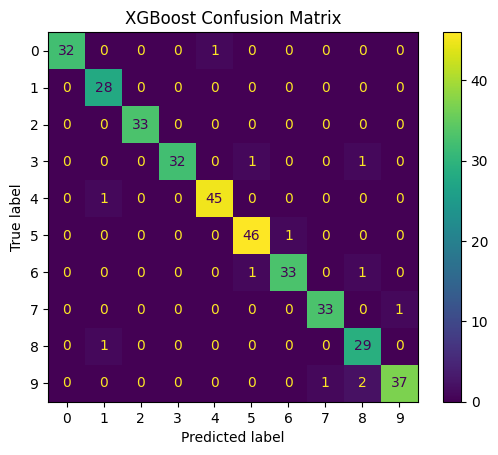

In [29]:
from xgboost import XGBClassifier

# Instantiate the XGBoost classifier with optimal parameters
xgb_cls = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Fit the model on the training data
xgb_cls.fit(x_train, y_train)

# Print the accuracy on the test set
print(f"XGBoost accuracy: {xgb_cls.score(x_test, y_test)}")

# Predict the labels for the test set
y_pred_xgb = xgb_cls.predict(x_test)

# Compute and display the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()